# Data Analytics — Train the Trainer
## Student Copy

**10 Days · 80 Hours · Google Colaboratory**
Aligned to the TESDA Competency Standards for Data Analytics Level III.

---
### How each day is structured

| Time | Segment |
|---|---|
| 8:00 – 9:00 | Lecture 1 |
| 9:00 – 10:00 | Hands-On 1 |
| 10:00 – 10:10 | Break |
| 10:10 – 10:40 | Analysis and Discussion 1 |
| 10:40 – 11:40 | Lecture 2 |
| 11:40 – 12:40 | Hands-On 2 |
| 12:40 – 1:40 | Lunch |
| 1:40 – 2:10 | Analysis and Discussion 2 |
| 2:10 – 3:10 | Lecture 3 |
| 3:10 – 4:10 | Hands-On 3 |
| 4:10 – 4:20 | Break |
| 4:20 – 4:50 | Analysis and Discussion 3 |
| 4:50 – 5:00 | Wrap-Up |

Fill in the cells marked `# your code here`. Your instructor has the answer key.

---
*Prepared by Nina Comia for the Department of Information and Communications Technology (DICT).*

## Setup — Run This First (Every Session)
Colab clears files when the runtime disconnects. If your variables vanish, run this cell again.

In [52]:
# ============================================================
# SETUP — run this cell first, every session.
# Creates the two course data files inside ./data/
#   service_requests.csv   (1,222 rows, with deliberate defects)
#   regional_offices.json  (9 offices, nested structure)
# ============================================================
import pandas as pd, numpy as np, json, random, os

np.random.seed(2026); random.seed(2026)
os.makedirs("data", exist_ok=True)

REGIONS = ["NCR", "Region III", "Region IV-A", "Region VI", "Region VII", "Region XI"]
OFFICES = {"NCR": ["DICT-NCR-01", "DICT-NCR-02"], "Region III": ["DICT-R3-01"],
           "Region IV-A": ["DICT-R4A-01", "DICT-R4A-02"], "Region VI": ["DICT-R6-01"],
           "Region VII": ["DICT-R7-01", "DICT-R7-02"], "Region XI": ["DICT-R11-01"]}
SERVICES = ["Free WiFi Installation", "Digital Literacy Training", "Business Permit Assistance",
            "ICT Equipment Request", "Cybersecurity Advisory", "eGov App Support"]
CHANNELS = ["Walk-in", "Online Portal", "Email", "Hotline", "Mobile App"]
STATUS = ["Resolved", "Pending", "Escalated", "Closed - No Action"]
AGE_GROUPS = ["18-24", "25-34", "35-44", "45-54", "55+"]

dates = pd.date_range("2025-01-01", "2025-12-31", freq="D")
rows = []
for i in range(1, 1201):
    region = random.choice(REGIONS)
    status = random.choices(STATUS, weights=[62, 20, 12, 6])[0]
    rows.append({
        "request_id": f"SR-2025-{i:05d}",
        "date_filed": random.choice(dates),
        "region": region,
        "office_code": random.choice(OFFICES[region]),
        "service_type": random.choice(SERVICES),
        "channel": random.choices(CHANNELS, weights=[30, 25, 15, 15, 15])[0],
        "status": status,
        "days_to_resolve": max(0, int(np.random.lognormal(1.6, 0.75))) if status in ("Resolved", "Closed - No Action") else np.nan,
        "satisfaction_rating": random.choice([1,2,3,4,5]) if status == "Resolved" else np.nan,
        "citizen_age_group": random.choice(AGE_GROUPS),
        "processing_fee": float(random.choice([0, 0, 0, 50, 100, 150, 200])),
    })
df = pd.DataFrame(rows)

# Inject realistic data-quality defects (used in the Day 5 cleaning lessons)
d = df.copy()
_ncr = d.index[d["region"] == "NCR"]
d.loc[pd.Index(np.random.RandomState(1).choice(_ncr, 40, replace=False)), "region"] = " ncr "
d.loc[d.sample(25, random_state=2).index, "service_type"] = "Free Wifi Installation"
d.loc[d.sample(30, random_state=3).index, "citizen_age_group"] = np.nan
d.loc[d.sample(18, random_state=4).index, "processing_fee"] = np.nan
d.loc[d.sample(8,  random_state=5).index, "days_to_resolve"] = 999
d = pd.concat([d, d.sample(22, random_state=6)])
d["date_filed"] = d["date_filed"].astype(str)
_mix = d.sample(60, random_state=7).index
d.loc[_mix, "date_filed"] = pd.to_datetime(d.loc[_mix, "date_filed"]).dt.strftime("%m/%d/%Y")
d = d.sample(frac=1, random_state=8).reset_index(drop=True)
d.to_csv("data/service_requests.csv", index=False)

CITIES = {"NCR": "Quezon City", "Region III": "San Fernando", "Region IV-A": "Calamba",
          "Region VI": "Iloilo City", "Region VII": "Cebu City", "Region XI": "Davao City"}
offices = []
for region, codes in OFFICES.items():
    for c_ in codes:
        offices.append({
            "office_code": c_,
            "office_name": f"DICT Field Office {c_.split('-')[-1]} - {region}",
            "location": {"region": region, "city": CITIES[region],
                         "coordinates": {"lat": round(random.uniform(6.0, 16.5), 4),
                                         "lon": round(random.uniform(120.0, 126.0), 4)}},
            "staff_count": random.randint(8, 45),
            "year_established": random.randint(2012, 2022),
            "annual_budget_php": random.randrange(2_000_000, 12_000_000, 250_000),
            "services_offered": random.sample(SERVICES, k=random.randint(3, 6)),
            "is_active": random.random() > 0.1,
        })
with open("data/regional_offices.json", "w") as f:
    json.dump({"agency": "Department of Information and Communications Technology",
               "dataset": "Regional Field Office Master Data", "as_of": "2025-12-31",
               "record_count": len(offices), "offices": offices}, f, indent=2)

print("Setup complete. Files in ./data/:")
for fn in sorted(os.listdir("data")):
    print("   ", fn)
print("\nCSV rows:", len(d), "| Offices:", len(offices))

Setup complete. Files in ./data/:
    regional_offices.json
    service_requests.csv
    service_requests_clean_v1.csv

CSV rows: 1222 | Offices: 9


---
# Day 6 — Applying Statistical Concepts and Analysis
*TESDA alignment: Apply statistical concepts and analysis*

## Lecture 1 — Central Tendency

Three ways to answer "what is typical?"

- **Mean.** The arithmetic average. Sensitive to extreme values.
- **Median.** The middle value when sorted. Resistant to extremes.
- **Mode.** The most frequent value. The only one that works for nominal data.

**The rule that matters:** when the mean is much larger than the median, the distribution is skewed to the right and a few large values are pulling the average up. Report both, or report the median alone.

Government service data is almost always right-skewed. Most requests resolve quickly; a small number drag on for months. Reporting only the mean makes the service look worse than most citizens experience.

In [53]:
import pandas as pd, numpy as np
raw = pd.read_csv("data/service_requests.csv")
clean = raw.drop_duplicates().copy()
clean["region"] = clean["region"].str.strip().str.upper()
clean["service_type"] = clean["service_type"].replace({"Free Wifi Installation": "Free WiFi Installation"})
clean["date_filed"] = pd.to_datetime(clean["date_filed"], format="mixed")

# 1
q1, q3 = clean["days_to_resolve"].quantile([0.25, 0.75])
upper_fence = q3 + 1.5 * (q3 - q1)
print(f"Upper fence: {upper_fence:.1f}")

# 2
outlier_count = (clean["days_to_resolve"] > upper_fence).sum()
sentinel_count = (clean["days_to_resolve"] == 999).sum()
print("Above fence:", outlier_count, "| Exactly 999:", sentinel_count)

# 3. Replace sentinels — they are placeholders, not measurements
clean.loc[clean["days_to_resolve"] == 999, "days_to_resolve"] = np.nan

# 4. Integrity checks
resolved = clean[clean["status"] == "Resolved"]
integrity = {
    "resolved_have_days": bool(resolved["days_to_resolve"].notna().all()),
    "dates_in_2025": bool(clean["date_filed"].dt.year.eq(2025).all()),
    "no_dup_ids": bool(~clean["request_id"].duplicated().any()),
}
for k, v in integrity.items():
    print(f"{'PASS' if v else 'FAIL'}  {k}")

# 5. Save versioned output — raw file stays untouched
clean.to_csv("data/service_requests_clean_v1.csv", index=False)
print("\nSaved data/service_requests_clean_v1.csv with", len(clean), "rows")

Upper fence: 18.0
Above fence: 41 | Exactly 999: 8
FAIL  resolved_have_days
PASS  dates_in_2025
PASS  no_dup_ids

Saved data/service_requests_clean_v1.csv with 1200 rows


In [54]:
import pandas as pd
clean = pd.read_csv("data/service_requests_clean_v1.csv")

days = clean["days_to_resolve"].dropna()
print(f"Mean:   {days.mean():.2f}")
print(f"Median: {days.median():.2f}")
print(f"Mode:   {days.mode()[0]:.0f}")
print(f"\nMean is {days.mean()/days.median():.1f}x the median -> right-skewed")

# Mode is the only valid 'typical' for a nominal column
print("\nMost common channel:", clean["channel"].mode()[0])

Mean:   6.50
Median: 5.00
Mode:   3

Mean is 1.3x the median -> right-skewed

Most common channel: Walk-in


In [55]:
print(clean["days_to_resolve"].quantile(0.25))
print(clean["days_to_resolve"].quantile(0.75))
print(clean["days_to_resolve"].quantile(0.75) - clean["days_to_resolve"].quantile(0.25))

3.0
8.0
5.0


### Hands-On 1 — Compute and Compare

Use `data/service_requests_clean_v1.csv`.

1. Compute `days_mean`, `days_median`, `days_mode` for `days_to_resolve`.
2. Compute `sat_mean` and `sat_median` for `satisfaction_rating`.
3. Store in `skew_direction` the string `"right"` or `"left"` for the resolution time distribution, based on comparing mean and median.
4. Store in `typical_service` the mode of `service_type`. State in a comment why mean and median are invalid for that column.

In [56]:
import pandas as pd

# ============================================================
# HANDS-ON 1 — COMPUTE AND COMPARE
# ============================================================

# Load the cleaned dataset created from the previous exercise.
clean = pd.read_csv("data/service_requests_clean_v1.csv")


# ------------------------------------------------------------
# STEP 1 — Compute central tendency for days_to_resolve
# ------------------------------------------------------------

# Select the days_to_resolve column.
# .dropna() removes missing values because requests that are
# not yet resolved do not have a resolution time.
days = clean["days_to_resolve"].dropna()

# MEAN = arithmetic average of all valid resolution times.
# The mean can be affected by unusually large values.
days_mean = days.mean()

# MEDIAN = middle value after the resolution times are sorted.
# The median is less affected by extreme values than the mean.
days_median = days.median()

# MODE = the value that occurs most frequently.
# .mode() can return more than one value, so [0] gets the first mode.
days_mode = days.mode()[0]


# ------------------------------------------------------------
# STEP 2 — Compute central tendency for satisfaction_rating
# ------------------------------------------------------------

# Select the satisfaction_rating column and remove missing values.
# Missing ratings occur for requests that were not Resolved.
sat = clean["satisfaction_rating"].dropna()

# Calculate the average satisfaction rating.
sat_mean = sat.mean()

# Calculate the middle satisfaction rating.
sat_median = sat.median()


# ------------------------------------------------------------
# STEP 3 — Determine the direction of skewness
# ------------------------------------------------------------

# Compare the mean and median of days_to_resolve.
#
# If MEAN > MEDIAN:
#   The larger values are pulling the mean upward.
#   This indicates a RIGHT-SKEWED distribution.
#
# If MEAN < MEDIAN:
#   The smaller values are pulling the mean downward.
#   This indicates a LEFT-SKEWED distribution.
if days_mean > days_median:
    skew_direction = "right"
else:
    skew_direction = "left"


# ------------------------------------------------------------
# STEP 4 — Find the typical service
# ------------------------------------------------------------

# service_type is a NOMINAL categorical variable.
# We cannot calculate a meaningful mean or median because
# service names are categories, not numerical measurements.
#
# Example:
# "Digital Literacy Training" + "eGov App Support"
# cannot be mathematically averaged.
#
# Therefore, MODE is the appropriate measure.
# It tells us which service type occurs most frequently.
typical_service = clean["service_type"].mode()[0]


# ------------------------------------------------------------
# STEP 5 — Display the answers
# ------------------------------------------------------------

print(days_mean, days_median, days_mode)
print(sat_mean, sat_median)
print(skew_direction, typical_service)


# NOTE:
# Mean, median, and mode are all measures of central tendency,
# but they are not appropriate for every type of data.
#
# Numerical data:
#   - Mean → average
#   - Median → middle value
#   - Mode → most frequent value
#
# Nominal categorical data:
#   - Mode → appropriate
#   - Mean → invalid
#   - Median → invalid
#
# For this exercise, service_type is nominal categorical data,
# so we use the MODE to identify the most common service.

6.499375780274657 5.0 3.0
2.972972972972973 3.0
right Free WiFi Installation


## Analysis and Discussion 1

### 1. Your mean resolution time is well above the median. Which number belongs in a press release, and which in an internal report?

**Answer:**

The **median** is more appropriate for a public-facing press release because it better represents the experience of a typical request when the data is right-skewed. The **mean** should still be included in an internal report because it shows the overall average and helps management identify the effect of unusually long cases.

- **Press release:** Median — better represents the typical citizen experience.
- **Internal report:** Mean and median — reporting both shows the typical experience and the effect of unusually long cases.

---

### 2. Satisfaction is ordinal. Is averaging it defensible? What would you report instead?

**Answer:**

Averaging an ordinal satisfaction rating such as 1–5 is **debatable** because the ratings have an order, but we cannot necessarily assume that the difference between each rating is equal.

For example, the difference between a rating of 1 and 2 may not represent the same amount of satisfaction change as the difference between 4 and 5.

A better approach is to report the **median satisfaction rating** together with the **percentage or number of responses for each rating (1–5)**. This preserves the ordinal nature of the data and provides more information about how citizens rated the service.

- **Possible summary:** Median satisfaction rating
- **More detailed reporting:** Distribution/percentage of ratings 1, 2, 3, 4, and 5
- **Mean:** Can be reported as a descriptive statistic if the organization treats the scale as approximately interval, but it should not be the only measure.

---

### 3. The mode of `days_to_resolve` is a low number. What does that say about most citizens' experience?

**Answer:**

A low mode means that the **most frequently occurring resolution time is relatively short**. This suggests that the most common experience is that requests are resolved quickly.

However, the mode does **not** mean that every citizen experiences that resolution time. It only identifies the most frequently occurring value. Some requests may take much longer and can pull the mean upward.

Therefore, the mode should be considered together with the **median and mean** to get a more complete picture of service performance.

## Lecture 2 — Diagnostic analytics and hypothesis testing

**Diagnostic analytics** analyzes historical datasets to uncover root causes, patterns and relationships. It uses techniques such as data mining, correlation analysis, drill-down methods and statistical modeling.
- Drill down analysis: breaking down metrics by different dimensions
- Root cause analysis (RCA): 5 why’s, Ishikawa (fishbone) diagram
- Pareto analysis: 80/20 rule states that roughly 80% of effects come from 20% of causes
- Statistical techniques such as regression analysis, hypothesis testing, cluster analysis, time-series decomposition


**Hypothesis testing** is a statistical method used to determine whether there is sufficient evidence to support a claim about a population.
- Null Hypothesis (H₀) – Assumes no significant difference, relationship, or effect.
- Alternative Hypothesis (H₁) – Represents the difference, relationship, or effect we are testing for.
- Significance Level (α) – The threshold for deciding whether the evidence is statistically significant, commonly 0.05.
- p-value – Indicates how likely the observed result would be if the null hypothesis were true.
  - p-value ≤ α → Reject H₀
  - p-value > α → Fail to reject H₀


,segment,sales,sales_share_pct,cumulative_pct
0,Sat Dinner,1778.40,36.84,36.84
1,Sun Dinner,1627.16,33.70,70.54
2,Thur Lunch,1077.55,22.32,92.86
3,Fri Dinner,235.96,4.89,97.75
4,Fri Lunch,89.92,1.86,99.61
5,Thur Dinner,18.78,0.39,100.00


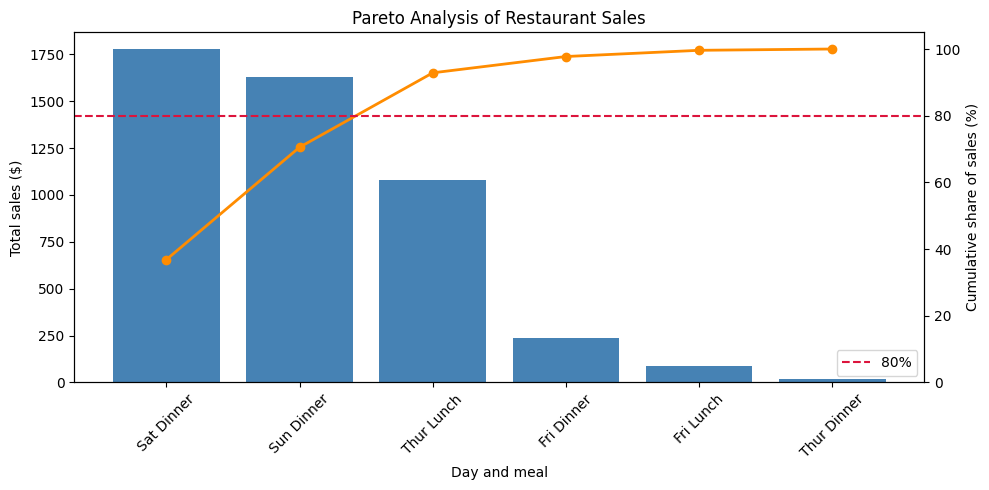

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load example restaurant transactions
df = sns.load_dataset("tips")

# Total sales by day and meal
pareto = (
    df.groupby(["day", "time"], observed=True)["total_bill"]
      .sum()
      .sort_values(ascending=False)
      .reset_index(name="sales")
)

pareto["segment"] = (
    pareto["day"].astype(str) + " " + pareto["time"].astype(str)
)
pareto["sales_share_pct"] = pareto["sales"] / pareto["sales"].sum() * 100
pareto["cumulative_pct"] = pareto["sales_share_pct"].cumsum()

display(pareto[[
    "segment", "sales", "sales_share_pct", "cumulative_pct"
]].round(2))

# Pareto chart
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(pareto["segment"], pareto["sales"], color="steelblue")
ax1.set_ylabel("Total sales ($)")
ax1.set_xlabel("Day and meal")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(
    pareto["segment"],
    pareto["cumulative_pct"],
    color="darkorange",
    marker="o",
    linewidth=2
)
ax2.axhline(80, color="crimson", linestyle="--", label="80%")
ax2.set_ylabel("Cumulative share of sales (%)")
ax2.set_ylim(0, 105)
ax2.legend(loc="lower right")

plt.title("Pareto Analysis of Restaurant Sales")
plt.tight_layout()
plt.show()

In [58]:
# 3. PAIRED t-TEST
# Did the SAME stores' average weekly sales change after a promotion?
# These store-level figures are SIMULATED for the demo.
rng = np.random.default_rng(42)
stores = pd.DataFrame({
    "store_id": range(1, 31),
    "before_sales": rng.normal(50000, 8000, 30).round(2)
})
stores["after_sales"] = (
    stores["before_sales"] + rng.normal(3000, 5000, 30)
).round(2)
stores["change"] = stores["after_sales"] - stores["before_sales"]

paired = stats.ttest_rel(
    stores["after_sales"], stores["before_sales"]
)

# h0 = mean(sales_before_promotion) - mean(sales_after_promotion) = 0
# h1 = mean(sales_before_promotion) - mean(sales_after_promotion) <> 0
# decision point: if p_value < 0.05, then reject null. Otherwise, fail to reject null
print("PAIRED: Same-store sales before vs. after")
print(f"Average change: {stores['change'].mean():,.2f}")
print(f"p-value: {paired.pvalue:.4f}")
print(f"95% CI for average change: {paired.confidence_interval()}")
display(stores.head())

PAIRED: Same-store sales before vs. after
Average change: 3,568.78
p-value: 0.0000
95% CI for average change: ConfidenceInterval(low=np.float64(2066.353673606158), high=np.float64(5071.214326393842))


,store_id,before_sales,after_sales,change
0,1,52437.74,66145.98,13708.24
1,2,41680.13,42648.05,967.92
2,3,56003.61,56442.40,438.79
3,4,57524.52,56455.66,-1068.86
4,5,34391.72,40471.62,6079.90


In [59]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Restaurant transactions: total_bill is the sale amount.
# Seaborn downloads this example dataset on first use.
sales = sns.load_dataset("tips")
display(sales.head())

# 1. ONE-SAMPLE t-TEST
# Is the average restaurant bill different from a $20 benchmark?
bills = sales["total_bill"].dropna()
one_sample = stats.ttest_1samp(bills, popmean=20)

# h0 = mean(bill) - $20 = 0
# h1 = mean(bill) - $20 <> 0
# decision point: if p_value < 0.05, then reject null. Otherwise, fail to reject null
print("ONE-SAMPLE: Average bill vs. $20")
print(f"Average bill: ${bills.mean():.2f}")
print(f"p-value: {one_sample.pvalue:.4f}")
print(f"95% CI for average bill: {one_sample.confidence_interval()}")
print()

# 2. INDEPENDENT TWO-SAMPLE t-TEST
# Do lunch and dinner customers have different average bills?
lunch = sales.loc[sales["time"] == "Lunch", "total_bill"].dropna()
dinner = sales.loc[sales["time"] == "Dinner", "total_bill"].dropna()

independent = stats.ttest_ind(
    lunch, dinner, equal_var=False  # Welch's t-test
)

print("INDEPENDENT: Lunch vs. dinner")
print(f"Lunch mean: ${lunch.mean():.2f}")
print(f"Dinner mean: ${dinner.mean():.2f}")
print(f"Mean difference (lunch − dinner): ${lunch.mean() - dinner.mean():.2f}")
print(f"p-value: {independent.pvalue:.4f}")
print(f"95% CI for difference: {independent.confidence_interval()}")
print()

# 3. PAIRED t-TEST
# Did the SAME stores' average weekly sales change after a promotion?
# These store-level figures are SIMULATED for the demo.
rng = np.random.default_rng(42)
stores = pd.DataFrame({
    "store_id": range(1, 31),
    "before_sales": rng.normal(50000, 8000, 30).round(2)
})
stores["after_sales"] = (
    stores["before_sales"] + rng.normal(3000, 5000, 30)
).round(2)
stores["change"] = stores["after_sales"] - stores["before_sales"]

paired = stats.ttest_rel(
    stores["after_sales"], stores["before_sales"]
)

print("PAIRED: Same-store sales before vs. after")
print(f"Average change: {stores['change'].mean():,.2f}")
print(f"p-value: {paired.pvalue:.4f}")
print(f"95% CI for average change: {paired.confidence_interval()}")
display(stores.head())

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


ONE-SAMPLE: Average bill vs. $20
Average bill: $19.79
p-value: 0.7075
95% CI for average bill: ConfidenceInterval(low=np.float64(18.663331704358473), high=np.float64(20.908553541543167))

INDEPENDENT: Lunch vs. dinner
Lunch mean: $17.17
Dinner mean: $20.80
Mean difference (lunch − dinner): $-3.63
p-value: 0.0022
95% CI for difference: ConfidenceInterval(low=np.float64(-5.925088453244516), high=np.float64(-1.3318767873971962))

PAIRED: Same-store sales before vs. after
Average change: 3,568.78
p-value: 0.0000
95% CI for average change: ConfidenceInterval(low=np.float64(2066.353673606158), high=np.float64(5071.214326393842))


,store_id,before_sales,after_sales,change
0,1,52437.74,66145.98,13708.24
1,2,41680.13,42648.05,967.92
2,3,56003.61,56442.40,438.79
3,4,57524.52,56455.66,-1068.86
4,5,34391.72,40471.62,6079.90


In [60]:
import pandas as pd
clean = pd.read_csv("data/service_requests_clean_v1.csv")
days = clean["days_to_resolve"].dropna()

print(days.describe().round(2))
print(f"\nStandard deviation: {days.std():.2f} days")
print(f"90th percentile: {days.quantile(0.90):.1f} days")
print(f"IQR (middle 50%): {days.quantile(0.75) - days.quantile(0.25):.1f} days")

count    801.00
mean       6.50
std        5.97
min        0.00
25%        3.00
50%        5.00
75%        8.00
max       45.00
Name: days_to_resolve, dtype: float64

Standard deviation: 5.97 days
90th percentile: 14.0 days
IQR (middle 50%): 5.0 days


### Hands-On 2 — Test Three Sales Questions
Use a simulated store sales dataset. Run the setup cell once to create store_sales.csv, then complete the exercise cell. Each row is one store, with average weekly sales before and after a promotion period.

Tasks
1. One-sample t-test: Is the average sales_before_php across all stores different from ₱50,000?
2. Independent two-sample t-test: Is average sales_after_php different between promotion and no-promotion stores? Use Welch's t-test.
3. Paired t-test: For the same promotion stores, did average sales change from before to after?
4. For each test, print the relevant mean or mean difference and p-value. At a significance level of 0.05, write one sentence interpreting the result.

In [65]:
# ============================================================
# SETUP — CREATE THE SIMULATED STORE SALES DATASET
# ============================================================

import pandas as pd
import numpy as np

# Create a random-number generator.
# Using a fixed seed makes the simulated data reproducible.
# This means you will get the same results each time you run it.
rng = np.random.default_rng(42)

# Total number of stores.
# We have 30 Promotion stores + 30 No-promotion stores.
n = 60

# Create the basic store information.
stores = pd.DataFrame({

    # Creates store IDs:
    # S001, S002, S003, ..., S060
    "store_id": [f"S{i:03d}" for i in range(1, n + 1)],

    # First 30 stores belong to the Promotion group.
    # Last 30 stores belong to the No-promotion group.
    "group": ["Promotion"] * 30 + ["No promotion"] * 30,

    # Simulate sales BEFORE the promotion period.
    #
    # mean = ₱50,000
    # standard deviation = ₱7,000
    # n = 60 stores
    "sales_before_php": rng.normal(
        50000,
        7000,
        n
    ).round(2)
})


# ------------------------------------------------------------
# CREATE THE CHANGE IN SALES
# ------------------------------------------------------------

# Promotion stores:
# Average simulated change is around +₱4,500.
#
# No-promotion stores:
# Average simulated change is around +₱800.
#
# The standard deviation of 4,000 means individual stores
# can have changes above or below these averages.
change = np.concatenate([

    # Change for 30 Promotion stores
    rng.normal(4500, 4000, 30),

    # Change for 30 No-promotion stores
    rng.normal(800, 4000, 30)
])


# ------------------------------------------------------------
# CALCULATE SALES AFTER THE PERIOD
# ------------------------------------------------------------

# After-sales = Before-sales + Change
stores["sales_after_php"] = (
    stores["sales_before_php"] + change
).round(2)


# ------------------------------------------------------------
# SAVE THE DATASET
# ------------------------------------------------------------

# This creates the CSV file that your exercise expects.
stores.to_csv("store_sales.csv", index=False)


# Check that the dataset was created correctly.
print("Dataset created successfully!")
print(f"Number of stores: {len(stores)}")
display(stores.head())

Dataset created successfully!
Number of stores: 60


,store_id,group,sales_before_php,sales_after_php
0,S001,Promotion,52133.02,49901.54
1,S002,Promotion,42720.11,45880.57
2,S003,Promotion,55253.16,60404.17
3,S004,Promotion,56583.95,63428.84
4,S005,Promotion,36342.75,43687.66


In [66]:
import pandas as pd
from scipy import stats

# Load the CSV file created by the setup cell.
stores = pd.read_csv("store_sales.csv")

# ============================================================
# TEST 1 — ONE-SAMPLE t-TEST
# ============================================================

# Question:
# Is the average sales_before_php across all stores
# different from ₱50,000?
#
# H₀: Mean sales_before_php = ₱50,000
# H₁: Mean sales_before_php ≠ ₱50,000

one_sample = stats.ttest_1samp(
    stores["sales_before_php"],
    popmean=50000
)

before_mean = stores["sales_before_php"].mean()
before_p = one_sample.pvalue

print("TEST 1 — One-sample t-test")
print(f"Mean sales before: ₱{before_mean:,.2f}")
print(f"p-value: {before_p:.4f}")

if before_p <= 0.05:
    print(
        "Interpretation: At α = 0.05, reject H₀; "
        "there is statistically significant evidence that "
        "average sales before the promotion differs from ₱50,000."
    )
else:
    print(
        "Interpretation: At α = 0.05, fail to reject H₀; "
        "there is insufficient evidence that average sales "
        "before the promotion differs from ₱50,000."
    )


# ============================================================
# TEST 2 — WELCH'S INDEPENDENT TWO-SAMPLE t-TEST
# ============================================================

# Question:
# Is average sales_after_php different between
# Promotion and No-promotion stores?
#
# H₀: Mean Promotion sales = Mean No-promotion sales
# H₁: Mean Promotion sales ≠ Mean No-promotion sales
#
# equal_var=False means we are using Welch's t-test.

promotion = stores.loc[
    stores["group"] == "Promotion",
    "sales_after_php"
]

no_promotion = stores.loc[
    stores["group"] == "No promotion",
    "sales_after_php"
]

independent = stats.ttest_ind(
    promotion,
    no_promotion,
    equal_var=False
)

promotion_mean = promotion.mean()
no_promotion_mean = no_promotion.mean()
after_difference = promotion_mean - no_promotion_mean
after_p = independent.pvalue

print("\nTEST 2 — Welch's independent two-sample t-test")
print(f"Promotion mean: ₱{promotion_mean:,.2f}")
print(f"No-promotion mean: ₱{no_promotion_mean:,.2f}")
print(f"Mean difference: ₱{after_difference:,.2f}")
print(f"p-value: {after_p:.4f}")

if after_p <= 0.05:
    print(
        "Interpretation: At α = 0.05, reject H₀; "
        "there is statistically significant evidence that "
        "average sales after the period differs between "
        "Promotion and No-promotion stores."
    )
else:
    print(
        "Interpretation: At α = 0.05, fail to reject H₀; "
        "there is insufficient evidence that average sales "
        "after the period differs between the two groups."
    )


# ============================================================
# TEST 3 — PAIRED t-TEST
# ============================================================

# Question:
# For the SAME Promotion stores, did average sales change
# from before to after?
#
# H₀: Mean change = 0
# H₁: Mean change ≠ 0
#
# We use the SAME stores before and after, so the observations
# are paired.

promotion_stores = stores[
    stores["group"] == "Promotion"
].copy()

# Calculate the change for each Promotion store.
# Positive = sales increased.
# Negative = sales decreased.
promotion_stores["change"] = (
    promotion_stores["sales_after_php"]
    - promotion_stores["sales_before_php"]
)

paired = stats.ttest_rel(
    promotion_stores["sales_after_php"],
    promotion_stores["sales_before_php"]
)

promotion_change = promotion_stores["change"].mean()
paired_p = paired.pvalue

print("\nTEST 3 — Paired t-test")
print(f"Average change: ₱{promotion_change:,.2f}")
print(f"p-value: {paired_p:.4f}")

if paired_p <= 0.05:
    print(
        "Interpretation: At α = 0.05, reject H₀; "
        "there is statistically significant evidence that "
        "average sales for the same Promotion stores changed "
        "from before to after the promotion period."
    )
else:
    print(
        "Interpretation: At α = 0.05, fail to reject H₀; "
        "there is insufficient evidence that average sales "
        "for the same Promotion stores changed from before "
        "to after the promotion period."
    )

TEST 1 — One-sample t-test
Mean sales before: ₱50,457.00
p-value: 0.5223
Interpretation: At α = 0.05, fail to reject H₀; there is insufficient evidence that average sales before the promotion differs from ₱50,000.

TEST 2 — Welch's independent two-sample t-test
Promotion mean: ₱54,211.31
No-promotion mean: ₱50,513.97
Mean difference: ₱3,697.35
p-value: 0.0236
Interpretation: At α = 0.05, reject H₀; there is statistically significant evidence that average sales after the period differs between Promotion and No-promotion stores.

TEST 3 — Paired t-test
Average change: ₱4,093.62
p-value: 0.0000
Interpretation: At α = 0.05, reject H₀; there is statistically significant evidence that average sales for the same Promotion stores changed from before to after the promotion period.


## **Analysis and Discussion 2**

### - In the one-sample test, how does the observed average before-sales compare with the ₱50,000 benchmark? What does the p-value add to that comparison?

The observed average before-sales was **₱50,457.00**, which is about **₱457 higher** than the ₱50,000 benchmark. However, the p-value was **0.5223**, which is greater than 0.05. Therefore, we **fail to reject the null hypothesis** and do not have sufficient statistical evidence that the true average before-sales differs from ₱50,000. The p-value helps determine whether the observed ₱457 difference is statistically significant rather than simply due to random variation in the sample.

### - In the independent test, which group has higher average after-sales? Does a statistically significant difference mean the promotion caused it? Explain.

The **Promotion** group had the higher average after-sales at **₱54,211.31**, compared with **₱50,513.97** for the No-promotion group. The p-value was **0.0236**, which is below 0.05, so there is statistically significant evidence that the groups' average after-sales differ. However, this result **does not by itself prove that the promotion caused the difference**, because this is an observational comparison between groups and other factors could have contributed to the difference. Statistical significance indicates evidence of a difference, not necessarily causation.

### - In the paired test, did most promotion stores improve, or was the average change driven by a few stores? Check the individual store changes before answering.

Most Promotion stores improved: **26 out of 30 stores increased their sales**, while only **4 stores decreased**. The average change was approximately **₱4,093.62**, and the paired t-test produced a p-value of approximately **0.0000000054**, which is far below 0.05. Because improvements occurred across most stores rather than only a few, the average increase was **not simply driven by a small number of stores**. Although some stores had larger increases than others, the overall pattern was broadly positive.


## Lecture 3 — Correlation and Regression

Correlation is a statistical measure that describes the strength and direction of a relationship between two variables.

**Linear regression** models the relationship between one or more independent variables and a single dependent variable.

Y = b_0 + b_1x

Where, X is the independent variable, Y is the dependent variable, b_0 is the intercept, b_1 is the slope. We get the b_0 and b_1 values where error is minimize.



### Hands-On 3 — Group Comparison and Correlation

target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64


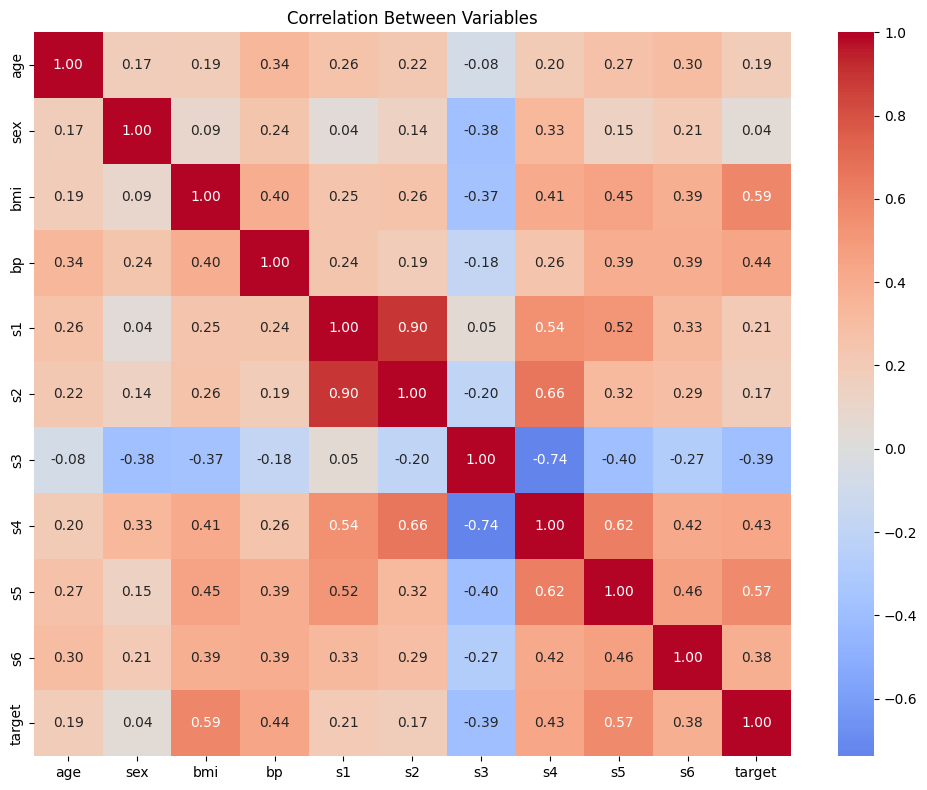

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

# Correlation of each variable with the numeric target
correlations = df.corr(numeric_only=True)["target"].sort_values(
    ascending=False
)
print(correlations)

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f",
            cmap="coolwarm", center=0)
plt.title("Correlation Between Variables")
plt.tight_layout()
plt.show()

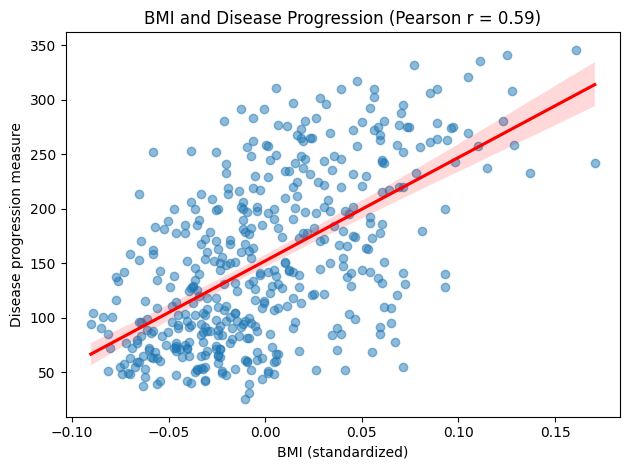

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes

df = load_diabetes(as_frame=True).frame

r = df["bmi"].corr(df["target"])

sns.regplot(
    data=df,
    x="bmi",
    y="target",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)

plt.title(f"BMI and Disease Progression (Pearson r = {r:.2f})")
plt.xlabel("BMI (standardized)")
plt.ylabel("Disease progression measure")
plt.tight_layout()
plt.show()

In [63]:
df["bmi"].describe()

,bmi
count,4.420000e+02
mean,-2.245564e-16
std,4.761905e-02
min,-9.027530e-02
25%,-3.422907e-02
50%,-7.283766e-03
75%,3.124802e-02
max,1.705552e-01


In [36]:
import statsmodels.api as sm


df = load_diabetes(as_frame=True).frame

X = sm.add_constant(df[["bmi"]])  # Adds the intercept
y = df["target"]

model = sm.OLS(y, X).fit()

print(model.summary())  # Full regression table
print("\nCoefficient p-values:")
print(model.pvalues)

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.344
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     230.7
Date:                Sat, 26 Sep 2026   Prob (F-statistic):           3.47e-42
Time:                        15:11:58   Log-Likelihood:                -2454.0
No. Observations:                 442   AIC:                             4912.
Df Residuals:                     440   BIC:                             4920.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      2.974     51.162      0.0

Intercept: 152.00
BMI coefficient: 998.58
Test MAE: 52.26
Test R²: 0.23


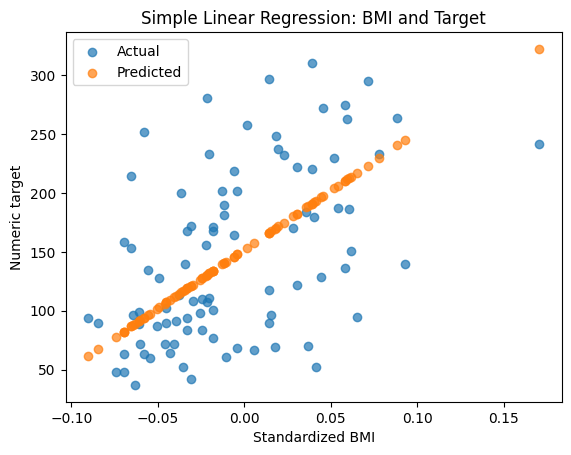

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X = df[["bmi"]]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(f"Intercept: {model.intercept_:.2f}")
print(f"BMI coefficient: {model.coef_[0]:.2f}")
print(f"Test MAE: {mean_absolute_error(y_test, predictions):.2f}")
print(f"Test R²: {r2_score(y_test, predictions):.2f}")

plt.scatter(X_test["bmi"], y_test, alpha=0.7, label="Actual")
plt.scatter(X_test["bmi"], predictions, alpha=0.7, label="Predicted")
plt.xlabel("Standardized BMI")
plt.ylabel("Numeric target")
plt.title("Simple Linear Regression: BMI and Target")
plt.legend()
plt.show()

### Hands-On 3 — Correlation and Simple Linear Regression
Use Seaborn’s diamonds dataset to investigate the relationship between a diamond’s weight (carat) and its price. This is a different dataset from the Diabetes example. Seaborn downloads the example data when first loaded in Colab.
Business question: Can carat weight help estimate a diamond’s price?
Tasks
1. Load the dataset and keep carat, price, and cut. Check for missing values.
2. Store the Pearson correlation between carat and price in carat_price_r.
3. Draw a scatterplot of carat against price. Describe its direction, shape, and spread.
4. Split the data into training and test sets. Fit a simple linear regression using carat to predict price.
5. Store the model’s slope in carat_coefficient, and calculate test_mae and test_r2.
6. Answer the discussion questions below.

Correlation:           carat     price
carat  1.000000  0.921591
price  0.921591  1.000000
Price change per additional carat: [7768.91049036]
Test MAE: 1009.504742060089
Test RMSE: 1549.6414599768207
Test R²: 0.824898284337539


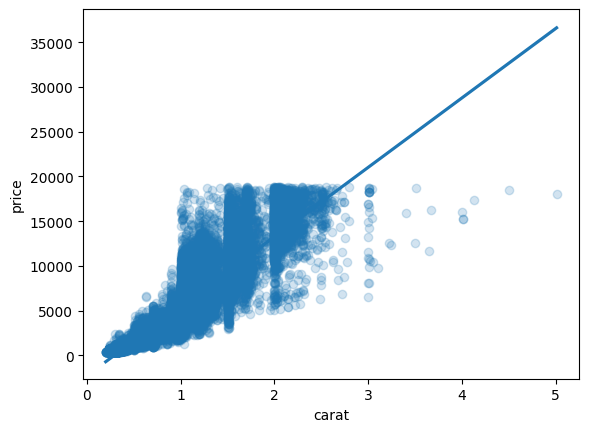

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error
)


# ============================================================
# 1. LOAD AND CHECK THE DATA
# ============================================================

# Load Seaborn's diamonds dataset.
# Keep only the columns needed for this exercise:
# carat = diamond weight
# price = diamond price
# cut = diamond cut quality
diamonds = sns.load_dataset("diamonds")[
    ["carat", "price", "cut"]
].dropna()

# Check whether there are missing values.
# Tip: use .isna().sum() to count missing values in each column.
# print(diamonds.isna().sum())


# ============================================================
# 2. CALCULATE THE PEARSON CORRELATION
# ============================================================

# Calculate the Pearson correlation between carat and price.
#
# Tip:
# You need ONE correlation value, not the entire correlation
# matrix.
#
# You can use:
# diamonds["carat"].corr(diamonds["price"])
#
# Store the result in carat_price_r.

# carat_price_r = ...


# ============================================================
# 3. DRAW A SCATTERPLOT
# ============================================================

# Create a scatterplot to investigate the relationship between
# carat and price.
#
# Put:
# - carat on the x-axis
# - price on the y-axis
#
# Tip:
# sns.scatterplot() is appropriate here.
# Use alpha=0.2 to make overlapping observations easier to see.

# sns.scatterplot(
#     data=diamonds,
#     x="carat",
#     y="price",
#     alpha=0.2
# )

# plt.show()


# ============================================================
# 4. PREPARE THE PREDICTOR AND OUTCOME
# ============================================================

# X is the predictor variable.
# We are using carat to predict price.
#
# Use double brackets for X because scikit-learn expects
# the predictor to be a 2-dimensional DataFrame.

X = diamonds[["carat"]]

# y is the outcome/target variable that we want to predict.
y = diamonds["price"]


# ============================================================
# 5. SPLIT THE DATA INTO TRAINING AND TEST SETS
# ============================================================

# Split the data into:
# - 80% training data
# - 20% test data
#
# random_state=42 makes the split reproducible.
#
# Tip:
# train_test_split() returns four objects:
# X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 6. FIT THE SIMPLE LINEAR REGRESSION MODEL
# ============================================================

# Create a LinearRegression model.
model = LinearRegression()

# Train/fit the model using ONLY the training data.
#
# Tip:
# The model learns the relationship between:
# X_train = carat
# y_train = price

# model.fit(X_train, y_train)


# ============================================================
# 7. MAKE PREDICTIONS
# ============================================================

# Use the trained model to predict prices for the TEST data.
#
# Important:
# Use X_test here because we want to evaluate how the model
# performs on data it did not use during training.

# predictions = model.predict(X_test)


# ============================================================
# 8. STORE THE MODEL'S SLOPE / COEFFICIENT
# ============================================================

# The model's coefficient represents the estimated change
# in diamond price for a 1-unit increase in carat.
#
# Tip:
# model.coef_ returns an array.
# Since we only have one predictor, use [0] to get the
# individual coefficient as a single number.

# carat_coefficient = ...


# ============================================================
# 9. EVALUATE THE MODEL
# ============================================================

# MAE = Mean Absolute Error.
#
# It tells us the average absolute difference between:
# actual prices and predicted prices.
#
# Tip:
# Put the actual values first and predictions second.

# test_mae = mean_absolute_error(y_test, predictions)


# R² measures how much variation in price is explained by
# the regression model.
#
# Again, use the actual test values and the predictions.

# test_r2 = r2_score(y_test, predictions)


# RMSE is another measure of prediction error.
# It gives more weight to larger errors.
#
# This is not specifically required in the task, but your
# existing code includes it, so you can keep it.

# test_rmse = root_mean_squared_error(y_test, predictions)


# ============================================================
# 10. DISPLAY THE RESULTS
# ============================================================

print("Correlation:", carat_price_r)
print("Price change per additional carat:", carat_coefficient)
print("Test MAE:", test_mae)
print("Test RMSE:", test_rmse)
print("Test R²:", test_r2)


# ============================================================
# 11. OPTIONAL: REGRESSION PLOT
# ============================================================

# regplot() combines a scatterplot with a fitted regression line.
#
# This helps you visually see the linear relationship learned
# by the model.

sns.regplot(
    data=diamonds,
    x="carat",
    y="price",
    scatter_kws={"alpha": 0.2}
)

plt.show()


# ============================================================
# DISCUSSION GUIDANCE
# ============================================================

# 1. Correlation:
# Look at carat_price_r.
#
# Ask:
# - Is it positive or negative?
# - Is it close to 0 or close to 1?
# - What does that tell you about the relationship?


# 2. Scatterplot:
# Describe three things:
# - Direction: Does price generally increase or decrease?
# - Shape: Does the relationship look roughly linear?
# - Spread: Do prices become more spread out at higher carat values?


# 3. Regression coefficient:
# carat_coefficient tells you the estimated price change
# associated with one additional carat.
#
# Ask:
# - Is the coefficient positive or negative?
# - What does its value mean in terms of price?


# 4. MAE:
# test_mae is measured in the same units as price.
#
# Ask:
# - Approximately how far away are the model's predictions
#   from the actual prices on average?


# 5. R²:
# test_r2 describes how much of the variation in price is
# explained by carat in this simple model.
#
# Ask:
# - Is the value relatively high or low?
# - What does this tell you about using carat alone?


# 6. Business question:
# "Can carat weight help estimate a diamond's price?"
#
# Base your answer on BOTH:
# - the correlation
# - the regression model's test performance
#
# Remember:
# A strong relationship does not mean carat is the only
# factor that determines price.

## Analysis and Discussion

### 1. Is the relationship between carat and price positive or negative? How strong is the linear correlation?

**Answer:**
The relationship between carat and price is **positive**. As carat weight increases, diamond price generally increases. The Pearson correlation is approximately **0.92**, indicating a **strong positive linear correlation** between carat and price.

### 2. What does the regression coefficient mean in the units of this dataset?

**Answer:**
The regression coefficient represents the estimated change in **price (US dollars)** for every **1-carat increase** in diamond weight. For example, if the coefficient is approximately **7,700**, the model estimates that the price increases by about **$7,700 for each additional carat**, on average.

This is an **association estimated by the model**, not proof that increasing carat weight by itself causes the price to increase.

### 3. If the test MAE is 1,000, what does that mean for a typical price prediction?

**Answer:**
A test MAE of **1,000** means that the model's predicted diamond prices differ from the actual prices by about **$1,000 on average**, in absolute terms, when evaluated on the test data.

For example, if the actual price is $5,000, a prediction might typically be around $1,000 higher or lower. MAE describes the average size of the errors; it does not mean that every prediction will be exactly $1,000 away.

### 4. Look at diamonds with similar carat weights. Do their prices still vary? Could cut help explain some of that variation?

**Answer:**
Yes. Diamonds with similar carat weights can still have noticeably different prices. This shows that carat does not explain all of the variation in diamond price.

**Cut could help explain some of this variation**, because diamond quality characteristics can affect price. Other variables in the dataset, such as color and clarity, may also contribute to differences in price.

### 5. Does the scatterplot suggest that one straight line describes the relationship equally well at small and large carat weights?

**Answer:**
Not necessarily. The scatterplot shows that the spread of prices tends to become **larger at higher carat weights**. The relationship also does not appear to follow a perfectly straight pattern across the entire range.

Therefore, a single straight-line regression is a useful simplification for describing the overall relationship, but it may not describe the relationship equally well for small and large diamonds.

### Teaching Note

A **strong correlation** and a **useful prediction model** show that carat weight is associated with diamond price and can help estimate price. However, they do **not establish that changing a diamond's weight by itself would cause the predicted price change**.

Diamond price is also influenced by quality characteristics such as **cut, color, and clarity**. Therefore, carat can be a useful predictor, but a model using carat alone does not capture all of the factors that determine diamond price.


In [41]:

diamonds.cut.unique()

['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Categories (5, object): ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']

In [42]:

import statsmodels.api as sm


df = sns.load_dataset("diamonds")[
    ["carat", "price", "cut"]
].dropna()
df["cut"] = df["cut"].replace({
    "Fair": 0,
    "Good": 1,
    "Very Good": 2,
    "Premium": 3,
    "Ideal": 4
})

X = sm.add_constant(df[["carat", "cut"]])  # Adds the intercept
y = df["price"]

model = sm.OLS(y, X).fit()

print(model.summary())  # Full regression table
print("\nCoefficient p-values:")
print(model.pvalues)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                 1.583e+05
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:12:03   Log-Likelihood:            -4.7180e+05
No. Observations:               53940   AIC:                         9.436e+05
Df Residuals:                   53937   BIC:                         9.436e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3071.0454     22.683   -135.389      0.0

/tmp/ipykernel_976/3979911275.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["cut"] = df["cut"].replace({
/tmp/ipykernel_976/3979911275.py:7: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["cut"] = df["cut"].replace({


In [43]:
df

,carat,price,cut
0,0.23,326,4
1,0.21,326,3
2,0.23,327,1
3,0.29,334,3
4,0.31,335,1
...,...,...,...
53935,0.72,2757,4
53936,0.72,2757,1
53937,0.70,2757,2
53938,0.86,2757,3


Weight–MPG correlation: -0.8317409332443352


<Axes: xlabel='weight', ylabel='mpg'>

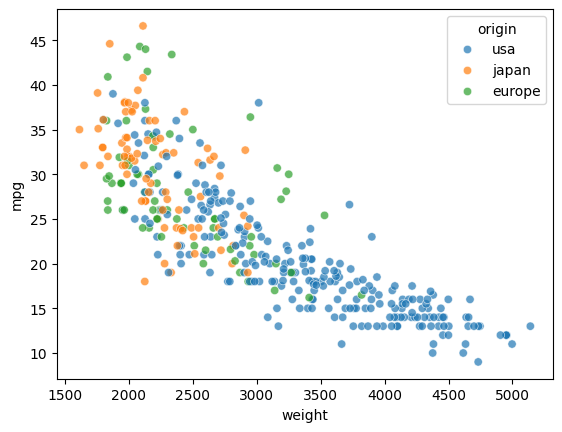

In [44]:
import seaborn as sns

df = sns.load_dataset("mpg")


df_copy = df.drop(labels=["name", "origin", "model_year"], axis=1)

# print(df.shape)
# display(df.head())
# display(df.isna().sum())
# display(df[["mpg", "weight", "horsepower"]].describe())


# Starting question for the correlation and regression stages
column = "weight"
print("Weight–MPG correlation:", df[column].corr(df["mpg"]))
sns.scatterplot(data=df, x=column, y="mpg", hue="origin", alpha=0.7)

<Axes: title={'center': 'mpg'}, xlabel='cylinders'>

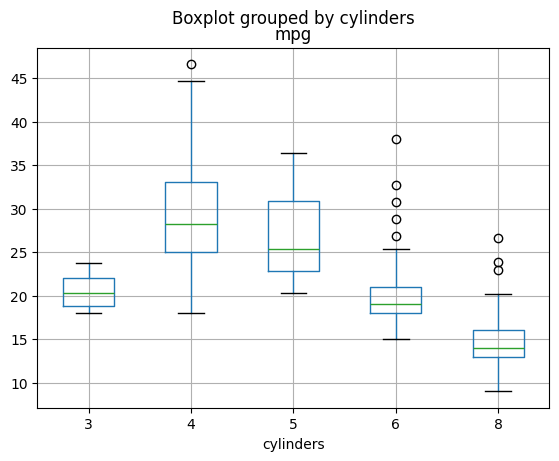

In [45]:
df.boxplot(
    column="mpg",
    by="cylinders"
)

In [46]:

from scipy import stats

cyl = 3
mpg_cyl = df[df["cylinders"]==cyl]["mpg"]

average = mpg_cyl.mean()
result = stats.ttest_1samp(mpg_cyl, popmean=23)
print(f"Mean: {average:4f}; p-value: {result.pvalue:.4f}")


Mean: 20.550000; p-value: 0.1520


In [47]:
df.drop(["mpg","model_year","origin","name"], axis=1).dropna()

,cylinders,displacement,horsepower,weight,acceleration
0,8,307.0,130.0,3504,12.0
1,8,350.0,165.0,3693,11.5
2,8,318.0,150.0,3436,11.0
3,8,304.0,150.0,3433,12.0
4,8,302.0,140.0,3449,10.5
...,...,...,...,...,...
393,4,140.0,86.0,2790,15.6
394,4,97.0,52.0,2130,24.6
395,4,135.0,84.0,2295,11.6
396,4,120.0,79.0,2625,18.6


In [48]:

import statsmodels.api as sm

X = sm.add_constant(df.drop(["mpg","model_year","origin","name"], axis=1).dropna())  # Adds the intercept
y = df.drop(["model_year","origin","name"], axis=1).dropna()["mpg"]

model = sm.OLS(y, X).fit()

print(model.summary())  # Full regression table
print("\nCoefficient p-values:")
print(model.pvalues)

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.704
Method:                 Least Squares   F-statistic:                     186.9
Date:                Sat, 26 Sep 2026   Prob (F-statistic):          9.82e-101
Time:                        15:12:04   Log-Likelihood:                -1120.1
No. Observations:                 392   AIC:                             2252.
Df Residuals:                     386   BIC:                             2276.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           46.2643      2.669     17.331   

In [49]:

round(-8.313e-05,5)

-8e-05

In [50]:
b0 = 46.2643
b_cylinder = -0.3979
b_displacement = -8.313e-05
b_horsepower =       -0.0453
b_weight       =   -0.0052
b_acceleration  =  -0.0291

x_cylinder = 8
x_displacement = 307
x_horsepower = 130
x_weight =3504
x_acceleration = 12


b0 + x_cylinder * b_cylinder + x_displacement * b_displacement + x_horsepower * b_horsepower + x_weight * b_weight + x_acceleration * b_acceleration


18.59657909

In [51]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
